# NMF sample structure

The committed CIBERSORT tutorial output provides 10 samples × 22 LM22 features. Factor selection is exploratory at this sample size.

Run from the `tutorials` directory in the prepared iobrx environment. Outputs are written to `extension-work/`; the figure uses a display-only feature z-score. No input values are normalized for the analysis unless the visible API parameters request it.

In [1]:
from pathlib import Path
from time import perf_counter
from contextlib import redirect_stdout, redirect_stderr
import io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iobrx
from _common import load, tpm_input, configure, runtime_info
from _extension_figures import plot_result

iobrx.set_threads(2)
slug = '15_nmf'
work = Path("extension-work") / slug
work.mkdir(parents=True, exist_ok=True)
print(json.dumps(runtime_info(), indent=2))
groups = None
configure()


{
  "iobrx": "0.3.0",
  "threads": 2,
  "native_available": true,
  "native_reason": null,
  "sorting": "numpy CPU dispatch",
  "requires_avx512": false,
  "bundled_openblas_found": true,
  "versions": {
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.7.2",
    "iobrpy": "0.2.1",
    "gseapy": "1.3.1",
    "matplotlib": "3.11.1"
  }
}


In [2]:
data = pd.read_csv("results/07_cibersort_result.csv", index_col=0).iloc[:, :22]

In [3]:
# Capture upstream progress messages; the computation remains the public API call below.
started = perf_counter()
with warnings.catch_warnings(record=True) as diagnostics, redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    result = iobrx.nmf(data, kmin=2, kmax=4, random_state=42, max_iter=1000, outdir=work)
elapsed = perf_counter() - started
for warning in diagnostics:
    print(f"{warning.category.__name__}: {warning.message}")
plot = pd.DataFrame(result["W"], index=data.index, columns=[f"Factor {i+1}" for i in range(result["best_k"])])
result["top_features"].to_csv(work / "top_features.csv")
tables = result if isinstance(result, dict) else {"result": result}
for name, table in tables.items():
    if isinstance(table, pd.DataFrame):
        table.to_csv(work / (name + ".csv"))
plot.to_csv(work / "display_source.csv")
timing = {"analysis": slug, "input_shape": list(data.shape), "seconds": elapsed, "threads": 2, "scope": "one API call; excludes input preparation", "fixture": 'The committed CIBERSORT tutorial output provides 10 samples × 22 LM22 features. Factor selection is exploratory at this sample size.'}
Path("results").mkdir(exist_ok=True)
Path("results", slug + "_timing.json").write_text(json.dumps(timing, indent=2) + "\n")
print(json.dumps(timing, indent=2))
display(plot.head())

{
  "analysis": "15_nmf",
  "input_shape": [
    10,
    22
  ],
  "seconds": 0.4645259100070689,
  "threads": 2,
  "scope": "one API call; excludes input preparation",
  "fixture": "The committed CIBERSORT tutorial output provides 10 samples \u00d7 22 LM22 features. Factor selection is exploratory at this sample size."
}


,Factor 1,Factor 2,Factor 3
TCGA-BR-6455,0.000000,0.000000,0.374077
TCGA-BR-7196,0.092466,0.131237,0.190878
TCGA-BR-8371,0.000000,0.681323,0.000000
TCGA-BR-8380,0.270784,0.076527,0.069845
TCGA-BR-8592,0.249150,0.122229,0.094924


findfont: Failed to find font weight medium, now using 400.


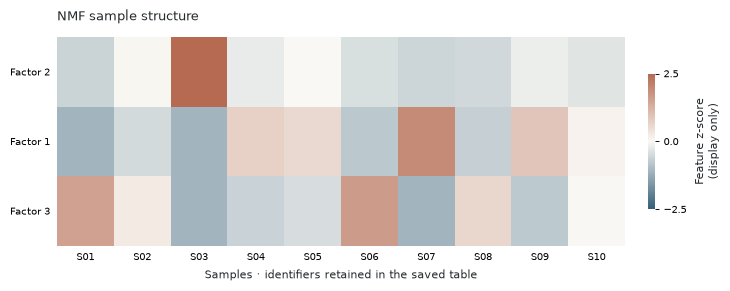

In [4]:
configure(2)
fig = plot_result(plot, 'NMF sample structure', 2, groups=groups)
for extension in ('png', 'pdf', 'svg'):
    fig.savefig(Path('figures') / (slug + '.' + extension), dpi=200, bbox_inches='tight')
review = Path('review/extensions')
review.mkdir(parents=True, exist_ok=True)
fig.savefig(review / (slug + '-round-2.png'), dpi=120, bbox_inches='tight')
plt.show()

Interpretation: the heatmap highlights relative patterns within each displayed feature. Colors are not cell fractions, statistical significance or cross-feature effect sizes. Full numeric outputs are saved separately. Runtime depends on hardware, input size, parameters and cache state.